In [8]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from collections import defaultdict

from constants import RANDOM_STATE

plt.style.use('bmh')

In [9]:
from constants import RANDOM_STATE

NUM_LAYERS = 24
SAMPLE_SIZE = 70
SENTENCE_CSV_PATH_HABE = "data/dataset_mgpt_haben.csv"
SENTENCE_CSV_PATH_EMPTY = "data/dataset_mgpt_empty.csv"
SENTENCE_CSV_PATH_SUBJECT = "data/dataset_mgpt_subject.csv"

# loading the sentence dataset
dataset_mgpt_habe_full = pd.read_csv(SENTENCE_CSV_PATH_HABE, index_col=0)
dataset_mgpt_habe_full['coll_freq_per_million'] = (dataset_mgpt_habe_full['coll_freq'] / dataset_mgpt_habe_full['obj_freq']) * 10**6
dataset_mgpt_habe = dataset_mgpt_habe_full.groupby('noun_ger').sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE) # equalizing the dataset

dataset_mgpt_empty_full = pd.read_csv(SENTENCE_CSV_PATH_EMPTY, index_col=0)
dataset_mgpt_empty_full['coll_freq_per_million'] = (dataset_mgpt_empty_full['coll_freq'] / dataset_mgpt_empty_full['obj_freq']) * 10**6
dataset_mgpt_empty = dataset_mgpt_empty_full.groupby('noun_ger').sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE) # equalizing the dataset


dataset_mgpt_subject_full = pd.read_csv(SENTENCE_CSV_PATH_SUBJECT, index_col=0)
dataset_mgpt_subject_full['coll_freq_per_million'] = (dataset_mgpt_subject_full['coll_freq'] / dataset_mgpt_subject_full['obj_freq']) * 10**6
dataset_mgpt_subject = dataset_mgpt_subject_full.groupby('noun_ger').sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE) # equalizing the dataset



In [10]:
dataset_mgpt_habe.head()

,sentence_f,sentence_e,coll_freq,logdice,obj_freq,perf_ger,perf_eng,past_eng,art_ger,noun_ger,...,top3_15_art_ger,top3_16_art_ger,top3_17_art_ger,top3_18_art_ger,top3_19_art_ger,top3_20_art_ger,top3_21_art_ger,top3_22_art_ger,top3_23_art_ger,coll_freq_per_million
115,Die Frau hat den Apfel dazugegeben,The woman added the apple,75,4.88,314787,dazugegeben,added,added,den,Apfel,...,True,False,False,False,False,True,True,True,True,238.256345
56,Ich habe den Apfel geraspelt,I grated the apple,157,6.74,314787,geraspelt,grated,grated,den,Apfel,...,True,False,False,False,True,True,True,True,True,498.749948
120,Ich habe den Apfel entdeckt,I discovered the apple,72,1.18,314787,entdeckt,discovered,discovered,den,Apfel,...,True,False,False,False,False,False,False,True,True,228.726091
30,Der Mann hat den Apfel gehalten,The man held the apple,358,1.91,314787,gehalten,held,held,den,Apfel,...,True,True,True,True,True,True,True,True,True,1137.276952
137,Er hat den Apfel gemalt,He painted the apple,57,3.41,314787,gemalt,painted,painted,den,Apfel,...,False,False,False,False,False,False,False,True,True,181.074822


In [11]:
dataset_mgpt_empty.head()

,sentence_f,sentence_e,coll_freq,logdice,obj_freq,perf_ger,perf_eng,past_eng,art_ger,noun_ger,...,top3_15_art_ger,top3_16_art_ger,top3_17_art_ger,top3_18_art_ger,top3_19_art_ger,top3_20_art_ger,top3_21_art_ger,top3_22_art_ger,top3_23_art_ger,coll_freq_per_million
115,Die Frau hat den Apfel dazugegeben,The woman added the apple,75,4.88,314787,dazugegeben,added,added,den,Apfel,...,False,False,False,False,False,False,False,False,False,238.256345
56,Ich habe den Apfel geraspelt,I grated the apple,157,6.74,314787,geraspelt,grated,grated,den,Apfel,...,False,False,False,False,False,False,False,False,False,498.749948
120,Ich habe den Apfel entdeckt,I discovered the apple,72,1.18,314787,entdeckt,discovered,discovered,den,Apfel,...,False,False,False,False,False,False,False,False,False,228.726091
30,Der Mann hat den Apfel gehalten,The man held the apple,358,1.91,314787,gehalten,held,held,den,Apfel,...,False,False,False,False,False,False,False,False,False,1137.276952
137,Er hat den Apfel gemalt,He painted the apple,57,3.41,314787,gemalt,painted,painted,den,Apfel,...,False,False,False,False,False,False,False,False,False,181.074822


In [12]:
dataset_mgpt_habe[dataset_mgpt_habe.art_ger == "den"].index

Int64Index([115,  56, 120,  30, 137, 118, 104,  78,  71, 135,
            ...
            954, 964, 904, 956, 979, 994, 980, 975, 940, 992],
           dtype='int64', length=280)

In [13]:
dataset_mgpt_habe['sentence_id'] = dataset_mgpt_habe.index
dataset_mgpt_empty['sentence_id'] = dataset_mgpt_empty.index
dataset_mgpt_subject['sentence_id'] = dataset_mgpt_subject.index


In [14]:
import torch

In [15]:
probs_full_mgpt_habe = []
for i in dataset_mgpt_habe_full.index:
    file = f"data/probs/mgpt_haben/{i}.pt"
    probs_full_mgpt_habe.append(torch.load(file))
probs_full_mgpt_habe = torch.stack(probs_full_mgpt_habe)
probs_full_mgpt_habe = probs_full_mgpt_habe[:, 1:, :]

In [16]:
probs_full_mgpt_empty = []
for i in dataset_mgpt_empty_full.index:
    file = f"data/probs/mgpt_empty/{i}.pt"
    probs_full_mgpt_empty.append(torch.load(file))
probs_full_mgpt_empty = torch.stack(probs_full_mgpt_empty)
probs_full_mgpt_empty = probs_full_mgpt_empty[:, 1:, :]

In [17]:
probs_full_mgpt_subject = []
for i in dataset_mgpt_subject_full.index:
    file = f"data/probs/mgpt_subject/{i}.pt"
    probs_full_mgpt_subject.append(torch.load(file))
probs_full_mgpt_subject = torch.stack(probs_full_mgpt_subject)
probs_full_mgpt_subject = probs_full_mgpt_subject[:, 1:, :]

In [21]:
probs_full_mgpt_empty.shape

torch.Size([1284, 24, 632])

In [28]:
probs_full_mgpt_habe.shape

torch.Size([1284, 24, 632])

In [29]:
probs_full_mgpt_subject.shape

torch.Size([1284, 24, 634])

In [11]:
probs_mgpt_habe_den = probs_full_mgpt_habe[dataset_mgpt_habe[dataset_mgpt_habe.art_ger == "den"].index]
probs_mgpt_habe_die = probs_full_mgpt_habe[dataset_mgpt_habe[dataset_mgpt_habe.art_ger == "die"].index]
probs_mgpt_habe_das = probs_full_mgpt_habe[dataset_mgpt_habe[dataset_mgpt_habe.art_ger == "das"].index]

probs_mgpt_empty_den = probs_full_mgpt_empty[dataset_mgpt_empty[dataset_mgpt_empty.art_ger == "den"].index]
probs_mgpt_empty_die = probs_full_mgpt_empty[dataset_mgpt_empty[dataset_mgpt_empty.art_ger == "die"].index]
probs_mgpt_empty_das = probs_full_mgpt_empty[dataset_mgpt_empty[dataset_mgpt_empty.art_ger == "das"].index]

probs_mgpt_subject_den = probs_full_mgpt_subject[dataset_mgpt_subject[dataset_mgpt_subject.art_ger == "den"].index]
probs_mgpt_subject_die = probs_full_mgpt_subject[dataset_mgpt_subject[dataset_mgpt_subject.art_ger == "die"].index]
probs_mgpt_subject_das = probs_full_mgpt_subject[dataset_mgpt_subject[dataset_mgpt_subject.art_ger == "das"].index]

In [13]:
probs_mgpt_subject_den.shape

torch.Size([280, 24, 632])

In [24]:
import json

with open("data/mgpt_tokenids.json") as f:
    token2id_mgpt = json.load(f)

In [25]:
token_ids_mgpt_sorted = sorted(token2id_mgpt.keys(), key = lambda x: token2id_mgpt[x])

In [26]:
len(token_ids_mgpt_sorted)

634

In [30]:
def word2prob(row, target_col, model_token_ids, layer, model_probs):
    word_id = model_token_ids.index(row[target_col])
    return model_probs[row['sentence_id'], layer, word_id].detach().numpy()

In [31]:
for l in range(NUM_LAYERS):
    dataset_mgpt_habe[f'perf_ger_layer_{l}_prob'] = dataset_mgpt_habe.apply(
        lambda row: word2prob(row, 'perf_ger', token_ids_mgpt_sorted, l, probs_full_mgpt_habe), axis=1
    ).astype('float')
    dataset_mgpt_habe[f'noun_ger_layer_{l}_prob'] = dataset_mgpt_habe.apply(
        lambda row: word2prob(row, 'noun_ger', token_ids_mgpt_sorted, l, probs_full_mgpt_habe), axis=1
    ).astype('float')
    dataset_mgpt_habe[f'perf_eng_layer_{l}_prob'] = dataset_mgpt_habe.apply(
        lambda row: word2prob(row, 'perf_eng', token_ids_mgpt_sorted, l, probs_full_mgpt_habe), axis=1
    ).astype('float')
    dataset_mgpt_habe[f'past_eng_layer_{l}_prob'] = dataset_mgpt_habe.apply(
        lambda row: word2prob(row, 'past_eng', token_ids_mgpt_sorted, l, probs_full_mgpt_habe), axis=1
    ).astype('float')
    dataset_mgpt_habe[f'noun_eng_layer_{l}_prob'] = dataset_mgpt_habe.apply(
        lambda row: word2prob(row, 'noun_eng', token_ids_mgpt_sorted, l, probs_full_mgpt_habe), axis=1
    ).astype('float')
    dataset_mgpt_habe[f'art_ger_layer_{l}_prob'] = dataset_mgpt_habe.apply(
        lambda row: word2prob(row, 'art_ger', token_ids_mgpt_sorted, l, probs_full_mgpt_habe), axis=1
    ).astype('float')
    dataset_mgpt_habe[f'impf_3_layer_{l}_prob'] = dataset_mgpt_habe.apply(
        lambda row: word2prob(row, 'impf_3', token_ids_mgpt_sorted, l, probs_full_mgpt_habe), axis=1
    ).astype('float')

    dataset_mgpt_empty[f'perf_ger_layer_{l}_prob'] = dataset_mgpt_empty.apply(
        lambda row: word2prob(row, 'perf_ger', token_ids_mgpt_sorted, l, probs_full_mgpt_empty), axis=1
    ).astype('float')
    dataset_mgpt_empty[f'noun_ger_layer_{l}_prob'] = dataset_mgpt_empty.apply(
        lambda row: word2prob(row, 'noun_ger', token_ids_mgpt_sorted, l, probs_full_mgpt_empty), axis=1
    ).astype('float')
    dataset_mgpt_empty[f'perf_eng_layer_{l}_prob'] = dataset_mgpt_empty.apply(
        lambda row: word2prob(row, 'perf_eng', token_ids_mgpt_sorted, l, probs_full_mgpt_empty), axis=1
    ).astype('float')
    dataset_mgpt_empty[f'past_eng_layer_{l}_prob'] = dataset_mgpt_empty.apply(
        lambda row: word2prob(row, 'past_eng', token_ids_mgpt_sorted, l, probs_full_mgpt_empty), axis=1
    ).astype('float')
    dataset_mgpt_empty[f'noun_eng_layer_{l}_prob'] = dataset_mgpt_empty.apply(
        lambda row: word2prob(row, 'noun_eng', token_ids_mgpt_sorted, l, probs_full_mgpt_empty), axis=1
    ).astype('float')
    dataset_mgpt_empty[f'art_ger_layer_{l}_prob'] = dataset_mgpt_empty.apply(
        lambda row: word2prob(row, 'art_ger', token_ids_mgpt_sorted, l, probs_full_mgpt_empty), axis=1
    ).astype('float')
    dataset_mgpt_empty[f'impf_3_layer_{l}_prob'] = dataset_mgpt_empty.apply(
        lambda row: word2prob(row, 'impf_3', token_ids_mgpt_sorted, l, probs_full_mgpt_empty), axis=1
    ).astype('float')


IndexError: index 633 is out of bounds for dimension 2 with size 632

In [39]:
for l in range(NUM_LAYERS):
    dataset_mgpt_subject[f'perf_ger_layer_{l}_prob'] = dataset_mgpt_subject.apply(
        lambda row: word2prob(row, 'perf_ger', token_ids_mgpt_sorted, l, probs_full_mgpt_subject), axis=1
    ).astype('float')
    dataset_mgpt_subject[f'noun_ger_layer_{l}_prob'] = dataset_mgpt_subject.apply(
        lambda row: word2prob(row, 'noun_ger', token_ids_mgpt_sorted, l, probs_full_mgpt_subject), axis=1
    ).astype('float')
    dataset_mgpt_subject[f'perf_eng_layer_{l}_prob'] = dataset_mgpt_subject.apply(
        lambda row: word2prob(row, 'perf_eng', token_ids_mgpt_sorted, l, probs_full_mgpt_subject), axis=1
    ).astype('float')
    dataset_mgpt_subject[f'past_eng_layer_{l}_prob'] = dataset_mgpt_subject.apply(
        lambda row: word2prob(row, 'past_eng', token_ids_mgpt_sorted, l, probs_full_mgpt_subject), axis=1
    ).astype('float')
    dataset_mgpt_subject[f'noun_eng_layer_{l}_prob'] = dataset_mgpt_subject.apply(
        lambda row: word2prob(row, 'noun_eng', token_ids_mgpt_sorted, l, probs_full_mgpt_subject), axis=1
    ).astype('float')
    dataset_mgpt_subject[f'art_ger_layer_{l}_prob'] = dataset_mgpt_subject.apply(
        lambda row: word2prob(row, 'art_ger', token_ids_mgpt_sorted, l, probs_full_mgpt_subject), axis=1
    ).astype('float')
    dataset_mgpt_subject[f'impf_3_layer_{l}_prob'] = dataset_mgpt_subject.apply(
        lambda row: word2prob(row, 'impf_3', token_ids_mgpt_sorted, l, probs_full_mgpt_subject), axis=1
    ).astype('float')
    dataset_mgpt_subject[f'aux_ger_layer_{l}_prob'] = dataset_mgpt_subject.apply(
        lambda row: word2prob(row, 'aux_ger', token_ids_mgpt_sorted, l, probs_full_mgpt_subject), axis=1
    ).astype('float')

In [88]:
dataset_mgpt_habe.head()

,sentence_f,sentence_e,coll_freq,logdice,obj_freq,perf_ger,perf_eng,past_eng,art_ger,noun_ger,...,noun_eng_layer_22_prob,art_ger_layer_22_prob,impf_3_layer_22_prob,perf_ger_layer_23_prob,noun_ger_layer_23_prob,perf_eng_layer_23_prob,past_eng_layer_23_prob,noun_eng_layer_23_prob,art_ger_layer_23_prob,impf_3_layer_23_prob
115,Die Frau hat den Apfel dazugegeben,The woman added the apple,75,4.88,314787,dazugegeben,added,added,den,Apfel,...,0.000668,0.070312,6.275177e-04,0.000248,0.000741,7.390976e-06,7.390976e-06,0.001723,0.165161,0.000654
56,Ich habe den Apfel geraspelt,I grated the apple,157,6.74,314787,geraspelt,grated,grated,den,Apfel,...,0.001391,0.078369,5.650520e-05,0.007038,0.001149,1.585388e-02,1.585388e-02,0.002672,0.141357,0.000114
120,Ich habe den Apfel entdeckt,I discovered the apple,72,1.18,314787,entdeckt,discovered,discovered,den,Apfel,...,0.001115,0.048889,6.389618e-05,0.010612,0.000242,2.115965e-05,2.115965e-05,0.002947,0.114136,0.000095
30,Der Mann hat den Apfel gehalten,The man held the apple,358,1.91,314787,gehalten,held,held,den,Apfel,...,0.000145,0.099731,3.576279e-07,0.000247,0.000612,5.960464e-08,5.960464e-08,0.001009,0.279785,0.000002
137,Er hat den Apfel gemalt,He painted the apple,57,3.41,314787,gemalt,painted,painted,den,Apfel,...,0.001111,0.064575,3.530502e-03,0.003210,0.000355,2.413988e-05,2.413988e-05,0.002579,0.085388,0.005997


In [49]:
print(dataset_mgpt_habe.groupby('layer_2_pred_1').count().sort_values('sentence_f').index[-1:-5:-1])
print(dataset_mgpt_habe.groupby('layer_3_pred_1').count().sort_values('sentence_f').index[-1:-5:-1])
print(dataset_mgpt_habe.groupby('layer_4_pred_1').count().sort_values('sentence_f').index[-1:-5:-1])
print(dataset_mgpt_habe.groupby('layer_5_pred_1').count().sort_values('sentence_f').index[-1:-5:-1])
print(dataset_mgpt_habe.groupby('layer_6_pred_1').count().sort_values('sentence_f').index[-1:-5:-1])
print(dataset_mgpt_habe.groupby('layer_7_pred_1').count().sort_values('sentence_f').index[-1:-5:-1])
print(dataset_mgpt_habe.groupby('layer_8_pred_1').count().sort_values('sentence_f').index[-1:-5:-1])
print(dataset_mgpt_habe.groupby('layer_9_pred_1').count().sort_values('sentence_f').index[-1:-5:-1])
print(dataset_mgpt_habe.groupby('layer_10_pred_1').count().sort_values('sentence_f').index[-1:-5:-1])
print(dataset_mgpt_habe.groupby('layer_11_pred_1').count().sort_values('sentence_f').index[-1:-5:-1])
print(dataset_mgpt_habe.groupby('layer_12_pred_1').count().sort_values('sentence_f').index[-1:-5:-1])
print(dataset_mgpt_habe.groupby('layer_13_pred_1').count().sort_values('sentence_f').index[-1:-5:-1])
print(dataset_mgpt_habe.groupby('layer_14_pred_1').count().sort_values('sentence_f').index[-1:-5:-1])
print(dataset_mgpt_habe.groupby('layer_15_pred_1').count().sort_values('sentence_f').index[-1:-5:-1])
print(dataset_mgpt_habe.groupby('layer_16_pred_1').count().sort_values('sentence_f').index[-1:-5:-1])
print(dataset_mgpt_habe.groupby('layer_17_pred_1').count().sort_values('sentence_f').index[-1:-5:-1])
print(dataset_mgpt_habe.groupby('layer_18_pred_1').count().sort_values('sentence_f').index[-1:-5:-1])
print(dataset_mgpt_habe.groupby('layer_19_pred_1').count().sort_values('sentence_f').index[-1:-5:-1])
print(dataset_mgpt_habe.groupby('layer_20_pred_1').count().sort_values('sentence_f').index[-1:-5:-1])
print(dataset_mgpt_habe.groupby('layer_21_pred_1').count().sort_values('sentence_f').index[-1:-5:-1])

Index(['Ġhat', 'Ġhad', 'Ġdas', 'Ġdie'], dtype='object', name='layer_2_pred_1')
Index(['Ġich', 'Ġk', 'Ġden', 'Ġgek'], dtype='object', name='layer_3_pred_1')
Index(['Ġgek', 'Ġsich', 'Ġdas', 'Ġmir'], dtype='object', name='layer_4_pred_1')
Index(['Ġdie', 'Ġeine', 'Ġkeinen', 'Ġgek'], dtype='object', name='layer_5_pred_1')
Index(['Ġdie', 'Ġsich', 'Ġeine', 'Ġkeiner'], dtype='object', name='layer_6_pred_1')
Index(['Ġdie', 'Ġdas', 'Ġmir', 'Ġhalt'], dtype='object', name='layer_7_pred_1')
Index(['Ġoffenbar', 'Ġhalt', 'Ġkeine', 'Ġeine'], dtype='object', name='layer_8_pred_1')
Index(['Ġeine', 'Ġhalt', 'Ġversucht', 'Ġoffenbar'], dtype='object', name='layer_9_pred_1')
Index(['Ġoffenbar', 'Ġeine', 'Ġdas', 'Ġdie'], dtype='object', name='layer_10_pred_1')
Index(['Ġgezeigt', 'Ġdie', 'Ġmich', 'Ġeine'], dtype='object', name='layer_11_pred_1')
Index(['Ġmich', 'Ġdie', 'Ġeine', 'Ġsich'], dtype='object', name='layer_12_pred_1')
Index(['Ġsich', 'Ġdie', 'Ġmich', 'Ġden'], dtype='object', name='layer_13_pred_1')
I

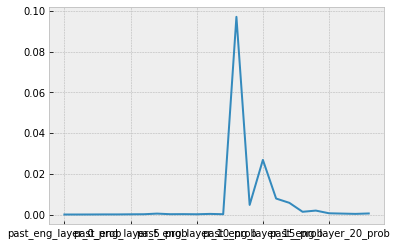

In [104]:
dataset_mgpt_habe[
    [f'past_eng_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean().plot()

In [105]:
dataset_mgpt_habe[
    [f'perf_eng_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()

perf_eng_layer_0_prob     2.393765e-07
perf_eng_layer_1_prob     3.848651e-06
perf_eng_layer_2_prob     1.924027e-05
perf_eng_layer_3_prob     4.982672e-05
perf_eng_layer_4_prob     4.559202e-05
perf_eng_layer_5_prob     1.041073e-04
perf_eng_layer_6_prob     1.371223e-04
perf_eng_layer_7_prob     4.403751e-04
perf_eng_layer_8_prob     1.554967e-04
perf_eng_layer_9_prob     1.895357e-04
perf_eng_layer_10_prob    1.270588e-04
perf_eng_layer_11_prob    2.983235e-04
perf_eng_layer_12_prob    1.456064e-04
perf_eng_layer_13_prob    9.704544e-02
perf_eng_layer_14_prob    4.705408e-03
perf_eng_layer_15_prob    2.680666e-02
perf_eng_layer_16_prob    7.837435e-03
perf_eng_layer_17_prob    5.730465e-03
perf_eng_layer_18_prob    1.335542e-03
perf_eng_layer_19_prob    1.927062e-03
perf_eng_layer_20_prob    6.056680e-04
perf_eng_layer_21_prob    4.511523e-04
perf_eng_layer_22_prob    3.081558e-04
perf_eng_layer_23_prob    5.126092e-04
dtype: float64

In [106]:
dataset_mgpt_habe[
    [f'perf_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()

perf_ger_layer_0_prob     0.000024
perf_ger_layer_1_prob     0.000195
perf_ger_layer_2_prob     0.000771
perf_ger_layer_3_prob     0.001055
perf_ger_layer_4_prob     0.001643
perf_ger_layer_5_prob     0.001482
perf_ger_layer_6_prob     0.000350
perf_ger_layer_7_prob     0.000286
perf_ger_layer_8_prob     0.000353
perf_ger_layer_9_prob     0.000657
perf_ger_layer_10_prob    0.000831
perf_ger_layer_11_prob    0.004974
perf_ger_layer_12_prob    0.001807
perf_ger_layer_13_prob    0.054096
perf_ger_layer_14_prob    0.080412
perf_ger_layer_15_prob    0.103875
perf_ger_layer_16_prob    0.105594
perf_ger_layer_17_prob    0.116266
perf_ger_layer_18_prob    0.112121
perf_ger_layer_19_prob    0.095677
perf_ger_layer_20_prob    0.082254
perf_ger_layer_21_prob    0.066786
perf_ger_layer_22_prob    0.038460
perf_ger_layer_23_prob    0.039472
dtype: float64

In [107]:
dataset_mgpt_habe[
    [f'art_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()

art_ger_layer_0_prob     0.000089
art_ger_layer_1_prob     0.013533
art_ger_layer_2_prob     0.039678
art_ger_layer_3_prob     0.039333
art_ger_layer_4_prob     0.027794
art_ger_layer_5_prob     0.038809
art_ger_layer_6_prob     0.040452
art_ger_layer_7_prob     0.030347
art_ger_layer_8_prob     0.021541
art_ger_layer_9_prob     0.016918
art_ger_layer_10_prob    0.026762
art_ger_layer_11_prob    0.027415
art_ger_layer_12_prob    0.031969
art_ger_layer_13_prob    0.099779
art_ger_layer_14_prob    0.065310
art_ger_layer_15_prob    0.143880
art_ger_layer_16_prob    0.136111
art_ger_layer_17_prob    0.129863
art_ger_layer_18_prob    0.152201
art_ger_layer_19_prob    0.171191
art_ger_layer_20_prob    0.250547
art_ger_layer_21_prob    0.248980
art_ger_layer_22_prob    0.245757
art_ger_layer_23_prob    0.213359
dtype: float64

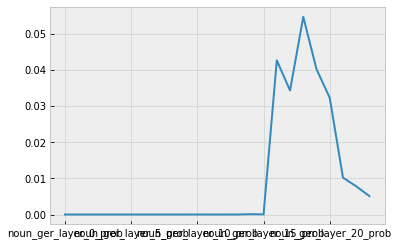

In [85]:
dataset_mgpt_habe[
    [f'noun_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean().plot()

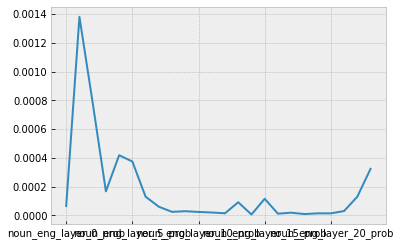

In [115]:
dataset_mgpt_habe[
    [f'noun_eng_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean().plot()

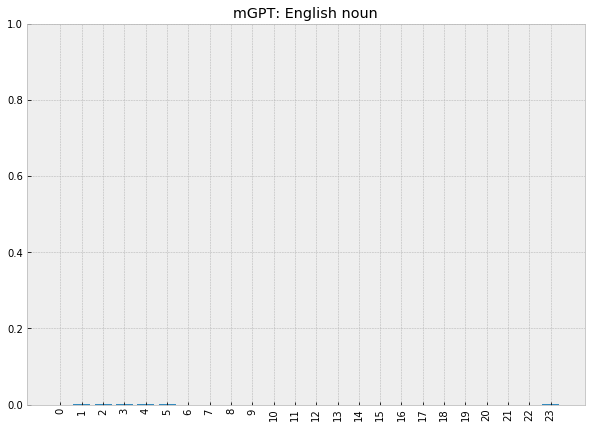

In [63]:
probs = dataset_mgpt_habe[
    [f'noun_eng_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()

fig, ax = plt.subplots(figsize=(10,7))
p = ax.bar(np.arange(NUM_LAYERS), probs)

plt.xticks(np.arange(NUM_LAYERS), rotation=90)
plt.ylim([0, 1])
plt.title("mGPT: English noun")
plt.show()

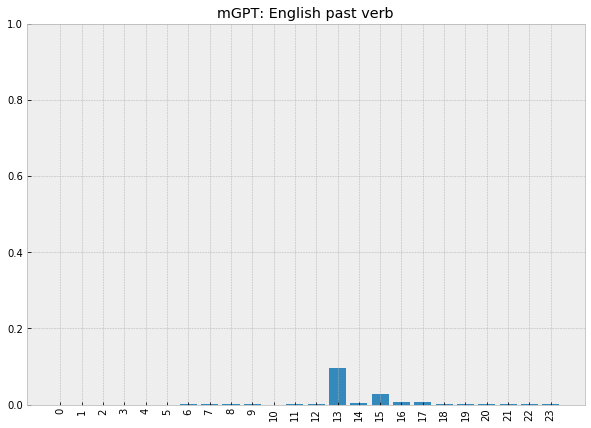

In [64]:
probs = dataset_mgpt_habe[
    [f'past_eng_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()

fig, ax = plt.subplots(figsize=(10,7))
p = ax.bar(np.arange(NUM_LAYERS), probs)

plt.xticks(np.arange(NUM_LAYERS), rotation=90)
plt.ylim([0, 1])
plt.title("mGPT: English past verb")
plt.show()

In [65]:
probs_full.shape

NameError: name 'probs_full' is not defined

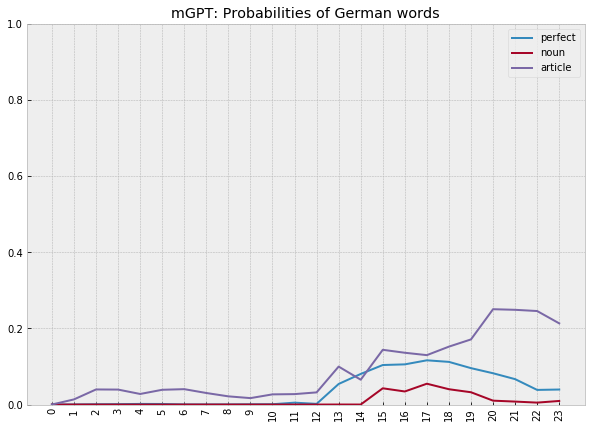

In [118]:
perf_ger_probs = dataset_mgpt_habe[
    [f'perf_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()
noun_ger_probs = dataset_mgpt_habe[
    [f'noun_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()
art_ger_probs = dataset_mgpt_habe[
    [f'art_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()

fig, ax = plt.subplots(figsize=(10,7))
p = ax.plot(np.arange(NUM_LAYERS), perf_ger_probs, label="perfect")
p = ax.plot(np.arange(NUM_LAYERS), noun_ger_probs, label="noun")
p = ax.plot(np.arange(NUM_LAYERS), art_ger_probs, label="article")


plt.xticks(np.arange(NUM_LAYERS), rotation=90)
plt.ylim([0, 1])
plt.title("mGPT: Probabilities of German words")
plt.legend()
plt.show()

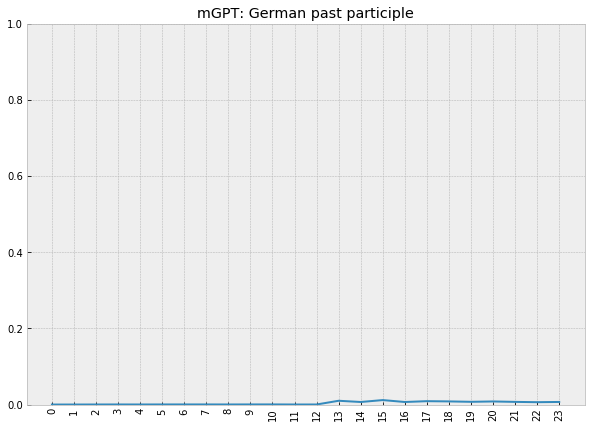

In [89]:
perf_ger_probs = dataset_mgpt_habe[
    [f'impf_3_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()

fig, ax = plt.subplots(figsize=(10,7))
p = ax.plot(np.arange(NUM_LAYERS), perf_ger_probs)

plt.xticks(np.arange(NUM_LAYERS), rotation=90)
plt.ylim([0, 1])
plt.title("mGPT: German past participle")
plt.show()

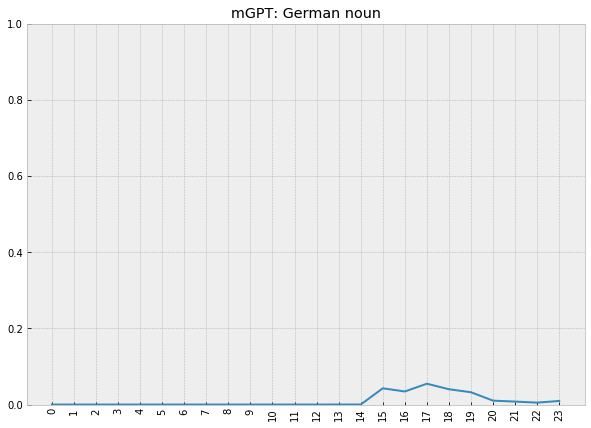

In [21]:
probs = dataset_mgpt_habe[
    [f'noun_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()

fig, ax = plt.subplots(figsize=(10,7))
p = ax.plot(np.arange(NUM_LAYERS), probs)

plt.xticks(np.arange(NUM_LAYERS), rotation=90)
plt.ylim([0, 1])
plt.title("mGPT: German noun")
plt.show()

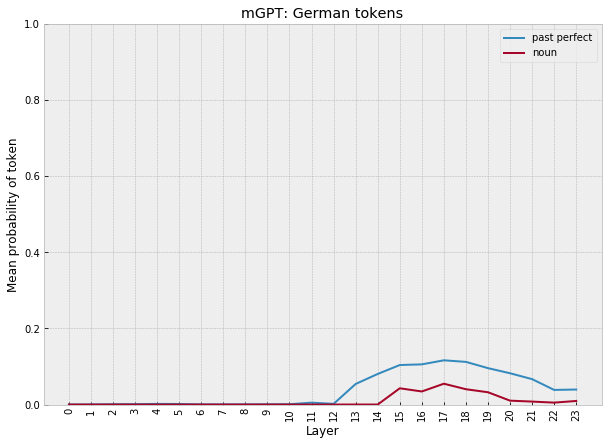

In [25]:
plot_perf_probs = dataset_mgpt_habe[
    [f'perf_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()
plot_noun_probs = dataset_mgpt_habe[
    [f'noun_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()
# plot_art_probs = dataset_gptj_habe[
#     [f'art_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
# ].mean()

fig, ax = plt.subplots(figsize=(10,7))
p = ax.plot(np.arange(NUM_LAYERS), plot_perf_probs, label="past perfect")
p = ax.plot(np.arange(NUM_LAYERS), plot_noun_probs, label="noun")
# p = ax.plot(np.arange(NUM_LAYERS), plot_art_probs)

plt.xticks(np.arange(NUM_LAYERS), rotation=90)
plt.ylim([0, 1])
plt.title("mGPT: German tokens")
plt.xlabel("Layer")
plt.ylabel("Mean probability of token")
plt.legend()
plt.show()

In [103]:
token_ids_mgpt_sorted.index('den')

51

In [109]:
probs_mgpt_den[:, 1:, token_ids_mgpt_sorted.index('die')].shape

torch.Size([280, 23])

ValueError: shape mismatch: objects cannot be broadcast to a single shape

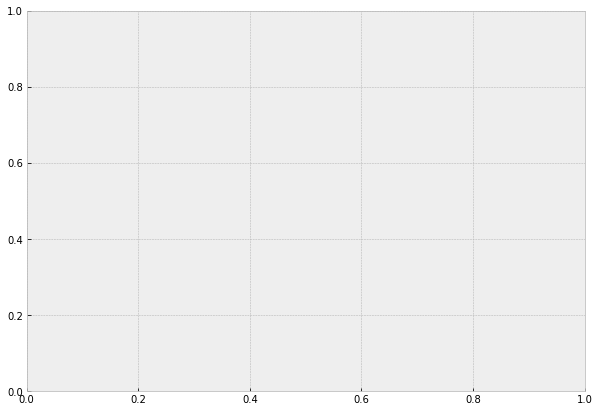

In [105]:
weigths_den = {
    "den": probs_mgpt_den[:, 1:, token_ids_mgpt_sorted.index('den')].mean(axis=0).detach().numpy(),
    "die": probs_mgpt_den[:, 1:, token_ids_mgpt_sorted.index('die')].mean(axis=0).detach().numpy(),
    "das": probs_mgpt_den[:, 1:, token_ids_mgpt_sorted.index('das')].mean(axis=0).detach().numpy()
}
width = 0.5

fig, ax = plt.subplots(figsize=(10,7))
bottom = np.zeros(NUM_LAYERS)

for article, weight_count in weigths_den.items():
    p = ax.bar(np.arange(NUM_LAYERS), weight_count, width, label=article, bottom=bottom)
    bottom += weight_count

# plt.plot(probs_den[:, 1:, 0].mean(axis=0).detach().numpy(), label="den")
# plt.plot(probs_den[:, 1:, 1].mean(axis=0).detach().numpy(), label="die")
# plt.plot(probs_den[:, 1:, 2].mean(axis=0).detach().numpy(), label="das")
# plt.ylim([0, 1])
plt.xticks(np.arange(NUM_LAYERS), rotation=90)

ax.legend()
plt.ylim([0, 1])
plt.title("mGPT: den after 'Ich habe'")
plt.xlabel("Layer")
plt.ylabel("Mean probability of token")
plt.show()


In [72]:
token_ids_mgpt_sorted.index('den')

19

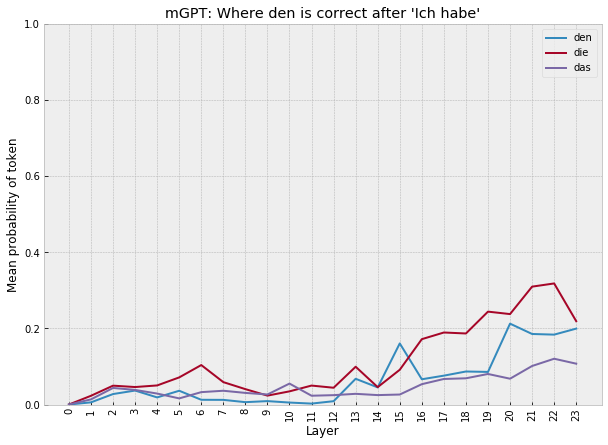

In [114]:
weigths_den = {
    "den": probs_mgpt_den[:, :, token_ids_mgpt_sorted.index('den')].mean(axis=0).detach().numpy(),
    "die": probs_mgpt_den[:, :, token_ids_mgpt_sorted.index('die')].mean(axis=0).detach().numpy(),
    "das": probs_mgpt_den[:, :, token_ids_mgpt_sorted.index('das')].mean(axis=0).detach().numpy()
}
width = 0.5

fig, ax = plt.subplots(figsize=(10,7))
bottom = np.zeros(NUM_LAYERS)

for article, weight_count in weigths_den.items():
    p = ax.plot(np.arange(NUM_LAYERS), weight_count, label=article)
#     bottom += weight_count

# plt.plot(probs_den[:, 1:, 0].mean(axis=0).detach().numpy(), label="den")
# plt.plot(probs_den[:, 1:, 1].mean(axis=0).detach().numpy(), label="die")
# plt.plot(probs_den[:, 1:, 2].mean(axis=0).detach().numpy(), label="das")
# plt.ylim([0, 1])
plt.xticks(np.arange(NUM_LAYERS), rotation=90)

ax.legend()
plt.ylim([0, 1])
plt.title("mGPT: Where den is correct after 'Ich habe'")
plt.xlabel("Layer")
plt.ylabel("Mean probability of token")
plt.show()

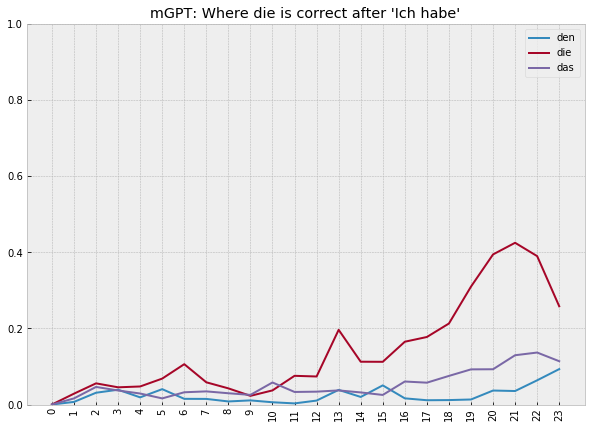

In [115]:
weigths_die = {
    "den": probs_mgpt_die[..., token_ids_mgpt_sorted.index('den')].mean(axis=0).detach().numpy(),
    "die": probs_mgpt_die[..., token_ids_mgpt_sorted.index('die')].mean(axis=0).detach().numpy(),
    "das": probs_mgpt_die[..., token_ids_mgpt_sorted.index('das')].mean(axis=0).detach().numpy()
}
width = 0.5

fig, ax = plt.subplots(figsize=(10,7))
bottom = np.zeros(NUM_LAYERS)

for article, weight_count in weigths_die.items():
    p = ax.plot(np.arange(NUM_LAYERS), weight_count, label=article)
#     bottom += weight_count

# plt.plot(probs_den[:, 1:, 0].mean(axis=0).detach().numpy(), label="den")
# plt.plot(probs_den[:, 1:, 1].mean(axis=0).detach().numpy(), label="die")
# plt.plot(probs_den[:, 1:, 2].mean(axis=0).detach().numpy(), label="das")
# plt.ylim([0, 1])
plt.xticks(np.arange(NUM_LAYERS), rotation=90)

ax.legend()
plt.ylim([0, 1])
plt.title("mGPT: Where die is correct after 'Ich habe'")
plt.show()


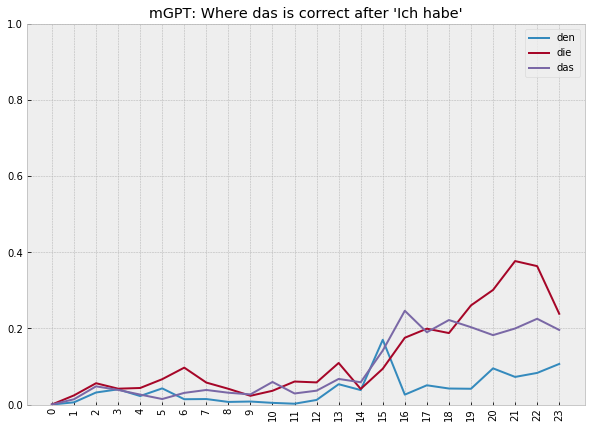

In [116]:
weigths_das = {
    "den": probs_mgpt_das[..., token_ids_mgpt_sorted.index('den')].mean(axis=0).detach().numpy(),
    "die": probs_mgpt_das[..., token_ids_mgpt_sorted.index('die')].mean(axis=0).detach().numpy(),
    "das": probs_mgpt_das[..., token_ids_mgpt_sorted.index('das')].mean(axis=0).detach().numpy()
}
width = 0.5

fig, ax = plt.subplots(figsize=(10,7))
bottom = np.zeros(NUM_LAYERS)

for article, weight_count in weigths_das.items():
    p = ax.plot(np.arange(NUM_LAYERS), weight_count, label=article)
#     bottom += weight_count

# plt.plot(probs_den[:, 1:, 0].mean(axis=0).detach().numpy(), label="den")
# plt.plot(probs_den[:, 1:, 1].mean(axis=0).detach().numpy(), label="die")
# plt.plot(probs_den[:, 1:, 2].mean(axis=0).detach().numpy(), label="das")
# plt.ylim([0, 1])
plt.xticks(np.arange(NUM_LAYERS), rotation=90)

ax.legend()
plt.ylim([0, 1])
plt.title("mGPT: Where das is correct after 'Ich habe'")
plt.show()


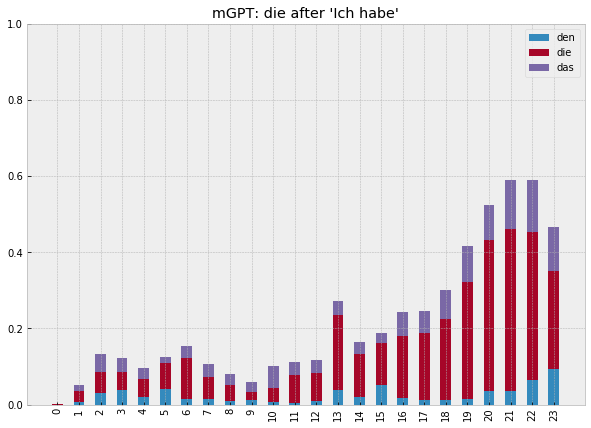

In [138]:
weigths_die = {
    "den": probs_die[:, 1:, token_ids_sorted.index('den')].mean(axis=0).detach().numpy(),
    "die": probs_die[:, 1:, token_ids_sorted.index('die')].mean(axis=0).detach().numpy(),
    "das": probs_die[:, 1:, token_ids_sorted.index('das')].mean(axis=0).detach().numpy()
}
width = 0.5

fig, ax = plt.subplots(figsize=(10,7))
bottom = np.zeros(NUM_LAYERS)

fig.size = (20, 20)

for article, weight_count in weigths_die.items():
    p = ax.bar(np.arange(NUM_LAYERS), weight_count, width, label=article, bottom=bottom)
    bottom += weight_count

# plt.plot(probs_den[:, 1:, 0].mean(axis=0).detach().numpy(), label="den")
# plt.plot(probs_den[:, 1:, 1].mean(axis=0).detach().numpy(), label="die")
# plt.plot(probs_den[:, 1:, 2].mean(axis=0).detach().numpy(), label="das")
# plt.ylim([0, 1])
plt.xticks(np.arange(NUM_LAYERS), rotation=90)

ax.legend()
plt.ylim([0, 1])
plt.title("mGPT: die after 'Ich habe'")
plt.show()

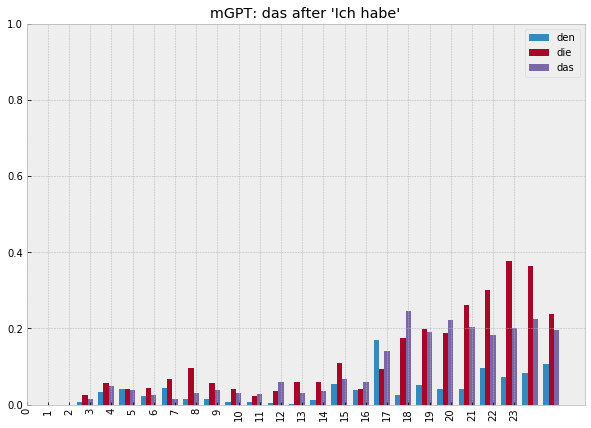

In [113]:
weigths_das = {
    "den": probs_das[:, 1:, token_ids_sorted.index('den')].mean(axis=0).detach().numpy(),
    "die": probs_das[:, 1:, token_ids_sorted.index('die')].mean(axis=0).detach().numpy(),
    "das": probs_das[:, 1:, token_ids_sorted.index('das')].mean(axis=0).detach().numpy()
}
width = 0.25

fig, ax = plt.subplots(figsize=(10,7))
bottom = np.zeros(NUM_LAYERS)

fig.size = (20, 20)

for article, weight_count in weigths_das.items():
    offset = width * multiplier
    p = ax.bar(np.arange(NUM_LAYERS) + offset, weight_count, width, label=article)
    bottom += weight_count
    multiplier += 1
#     p = ax.bar(np.arange(NUM_LAYERS), weight_count, width, label=article, bottom=bottom)
#     bottom += weight_count

# plt.plot(probs_den[:, 1:, 0].mean(axis=0).detach().numpy(), label="den")
# plt.plot(probs_den[:, 1:, 1].mean(axis=0).detach().numpy(), label="die")
# plt.plot(probs_den[:, 1:, 2].mean(axis=0).detach().numpy(), label="das")
# plt.ylim([0, 1])
plt.xticks(np.arange(NUM_LAYERS), rotation=90)

ax.legend()
plt.ylim([0, 1])
plt.title("mGPT: das after 'Ich habe'")
plt.show()

In [ ]:
weigths_den = {
    "eng": probs_den[:, 1:, token_ids_sorted.index('den')].mean(axis=0).detach().numpy(),
    "ger": probs_den[:, 1:, token_ids_sorted.index('den')].mean(axis=0).detach().numpy(),
}
width = 0.5

fig, ax = plt.subplots(figsize=(10,7))
bottom = np.zeros(NUM_LAYERS)

for article, weight_count in weigths_den.items():
    p = ax.bar(np.arange(NUM_LAYERS), weight_count, width, label=article, bottom=bottom)
    bottom += weight_count

# plt.plot(probs_den[:, 1:, 0].mean(axis=0).detach().numpy(), label="den")
# plt.plot(probs_den[:, 1:, 1].mean(axis=0).detach().numpy(), label="die")
# plt.plot(probs_den[:, 1:, 2].mean(axis=0).detach().numpy(), label="das")
# plt.ylim([0, 1])
plt.xticks(np.arange(NUM_LAYERS), rotation=90)

ax.legend()
plt.ylim([0, 1])
plt.title("mGPT: den after 'Ich habe'")
plt.show()


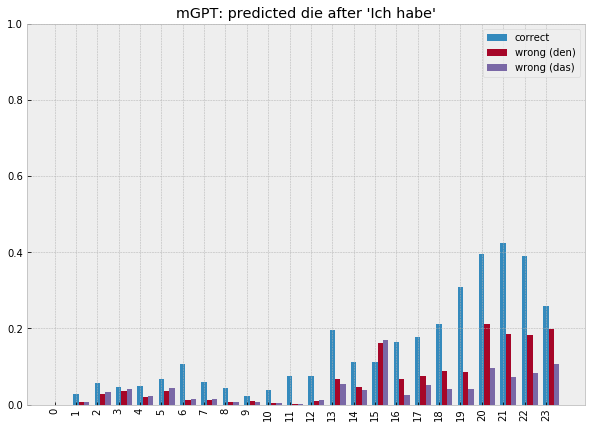

In [111]:
weigths_die_wrong = {
    "correct": probs_die[:, 1:, token_ids_sorted.index('die')].mean(axis=0).detach().numpy(),
    "wrong (den)": probs_den[:, 1:, token_ids_sorted.index('den')].mean(axis=0).detach().numpy(),
    "wrong (das)": probs_das[:, 1:, token_ids_sorted.index('den')].mean(axis=0).detach().numpy()
}
width = 0.25

fig, ax = plt.subplots(figsize=(10,7))
bottom = np.zeros(NUM_LAYERS)
multiplier = 0

fig.size = (20, 20)

for article, weight_count in weigths_die_wrong.items():
    offset = width * multiplier
    p = ax.bar(np.arange(NUM_LAYERS) + offset, weight_count, width, label=article)
    bottom += weight_count
    multiplier += 1

# plt.plot(probs_den[:, 1:, 0].mean(axis=0).detach().numpy(), label="den")
# plt.plot(probs_den[:, 1:, 1].mean(axis=0).detach().numpy(), label="die")
# plt.plot(probs_den[:, 1:, 2].mean(axis=0).detach().numpy(), label="das")
# plt.ylim([0, 1])
plt.xticks(np.arange(NUM_LAYERS), rotation=90)

ax.legend()
plt.ylim([0, 1])
plt.title("mGPT: predicted die after 'Ich habe'")
plt.show()

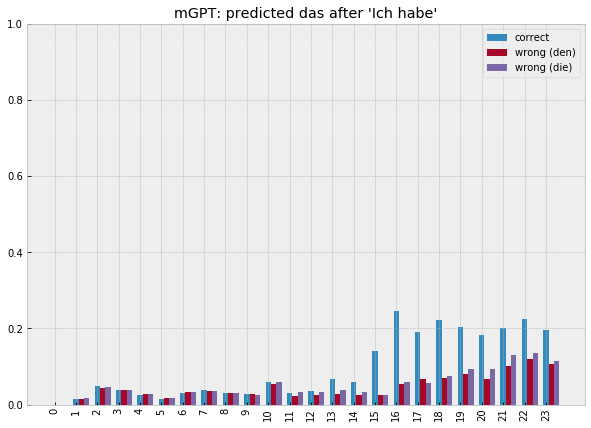

In [99]:
weigths_das_wrong = {
    "correct": probs_das[:, 1:, 2].mean(axis=0).detach().numpy(),
    "wrong (den)": probs_den[:, 1:, 2].mean(axis=0).detach().numpy(),
    "wrong (die)": probs_die[:, 1:, 2].mean(axis=0).detach().numpy()
}
width = 0.25

fig, ax = plt.subplots(figsize=(10,7))
bottom = np.zeros(NUM_LAYERS)
multiplier = 0

fig.size = (20, 20)

for article, weight_count in weigths_das_wrong.items():
    offset = width * multiplier
    p = ax.bar(np.arange(NUM_LAYERS) + offset, weight_count, width, label=article)
    bottom += weight_count
    multiplier += 1

# plt.plot(probs_den[:, 1:, 0].mean(axis=0).detach().numpy(), label="den")
# plt.plot(probs_den[:, 1:, 1].mean(axis=0).detach().numpy(), label="die")
# plt.plot(probs_den[:, 1:, 2].mean(axis=0).detach().numpy(), label="das")
# plt.ylim([0, 1])
plt.xticks(np.arange(NUM_LAYERS), rotation=90)

ax.legend()
plt.ylim([0, 1])
plt.title("mGPT: predicted das after 'Ich habe'")
plt.show()

In [51]:
np.arange(NUM_LAYERS)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

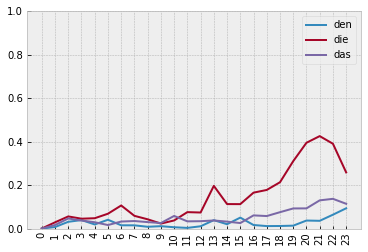

In [36]:
plt.plot(probs_die[:, 1:, 0].mean(axis=0).detach().numpy(), label="den")
plt.plot(probs_die[:, 1:, 1].mean(axis=0).detach().numpy(), label="die")
plt.plot(probs_die[:, 1:, 2].mean(axis=0).detach().numpy(), label="das")
plt.ylim([0, 1])
plt.xticks(np.arange(NUM_LAYERS), rotation=90)
plt.legend()

plt.show()

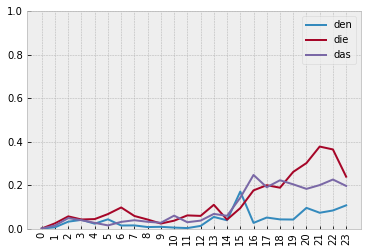

In [37]:
plt.plot(probs_das[:, 1:, 0].mean(axis=0).detach().numpy(), label="den")
plt.plot(probs_das[:, 1:, 1].mean(axis=0).detach().numpy(), label="die")
plt.plot(probs_das[:, 1:, 2].mean(axis=0).detach().numpy(), label="das")
plt.ylim([0, 1])
plt.xticks(np.arange(NUM_LAYERS), rotation=90)
plt.legend()

plt.show()

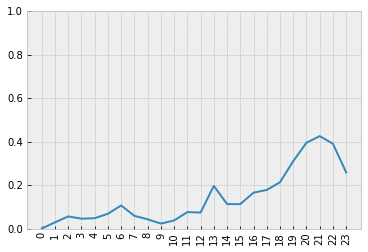

In [32]:
plt.plot(probs_die[:, 1:, 1].mean(axis=0).detach().numpy())
plt.ylim([0, 1])
plt.xticks(np.arange(NUM_LAYERS), rotation=90)

plt.show()

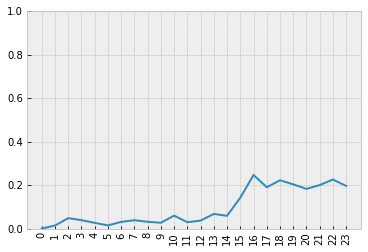

In [33]:
plt.plot(probs_das[:, 1:, 2].mean(axis=0).detach().numpy())
plt.ylim([0, 1])
plt.xticks(np.arange(NUM_LAYERS), rotation=90)

plt.show()

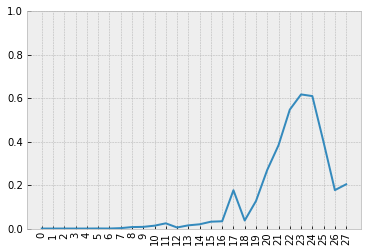

In [33]:
plt.plot(probs[:, 1:, 1].mean(axis=0).detach().numpy())
plt.ylim([0, 1])
plt.xticks(np.arange(NUM_LAYERS), rotation=90)

plt.show()

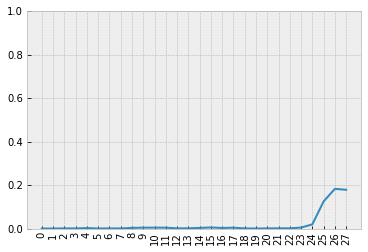

In [34]:
plt.plot(probs[:, 1:, 2].mean(axis=0).detach().numpy())
plt.ylim([0, 1])
plt.xticks(np.arange(NUM_LAYERS), rotation=90)

plt.show()

# GPT-J

In [131]:
from constants import RANDOM_STATE

NUM_LAYERS = 28
SAMPLE_SIZE = 70
SENTENCE_CSV_PATH = "data/dataset_gptj_haben.csv"

# loading the sentence dataset
dataset_gptj_habe_full = pd.read_csv(SENTENCE_CSV_PATH, index_col=0)
dataset_gptj_habe_full['coll_freq_per_million'] = (dataset_gptj_habe_full['coll_freq'] / dataset_gptj_habe_full['obj_freq']) * 10**6
dataset_gptj_habe = dataset_gptj_habe_full.groupby('noun_ger').sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE) # equalizing the dataset


In [132]:
dataset_gptj_habe['sentence_id'] = dataset_gptj_habe.index

In [133]:
dataset_gptj_habe.head()

,sentence_f,sentence_e,coll_freq,logdice,obj_freq,perf_ger,perf_eng,past_eng,art_ger,noun_ger,...,top3_20_art_ger,top3_21_art_ger,top3_22_art_ger,top3_23_art_ger,top3_24_art_ger,top3_25_art_ger,top3_26_art_ger,top3_27_art_ger,coll_freq_per_million,sentence_id
115,Die Frau hat den Apfel dazugegeben,The woman added the apple,75,4.88,314787,dazugegeben,added,added,den,Apfel,...,False,False,False,True,True,True,True,True,238.256345,115
56,Ich habe den Apfel geraspelt,I grated the apple,157,6.74,314787,geraspelt,grated,grated,den,Apfel,...,False,False,True,True,True,True,True,True,498.749948,56
120,Ich habe den Apfel entdeckt,I discovered the apple,72,1.18,314787,entdeckt,discovered,discovered,den,Apfel,...,False,False,True,True,True,True,True,True,228.726091,120
30,Der Mann hat den Apfel gehalten,The man held the apple,358,1.91,314787,gehalten,held,held,den,Apfel,...,False,False,True,True,True,True,True,True,1137.276952,30
137,Er hat den Apfel gemalt,He painted the apple,57,3.41,314787,gemalt,painted,painted,den,Apfel,...,True,True,True,True,True,True,True,True,181.074822,137


In [214]:
probs_full_gptj = []
for i in dataset_gptj_habe_full.index:
    file = f"data/probs/gptj_haben/{i}.pt"
    probs_full_gptj.append(torch.load(file))
probs_full_gptj = torch.stack(probs_full_gptj)
probs_full_gptj = probs_full_gptj[:, 1:, :]

In [216]:
probs_gptj = probs_full_gptj[dataset_gptj_habe.index]

In [217]:
probs_gptj.shape

torch.Size([560, 28, 421])

In [218]:
with open("data/gptj_tokenids.json") as f:
    token2id_gptj = json.load(f)

In [219]:
token_ids_gptj_sorted = sorted(token2id_gptj.keys(), key = lambda x: token2id_gptj[x])

In [220]:
probs_den_gptj = probs_full_gptj[dataset_gptj_habe[dataset_gptj_habe.art_ger == "den"].index]
probs_die_gptj = probs_full_gptj[dataset_gptj_habe[dataset_gptj_habe.art_ger == "die"].index]
probs_das_gptj = probs_full_gptj[dataset_gptj_habe[dataset_gptj_habe.art_ger == "das"].index]

In [221]:
probs_den_gptj.shape

torch.Size([280, 28, 421])

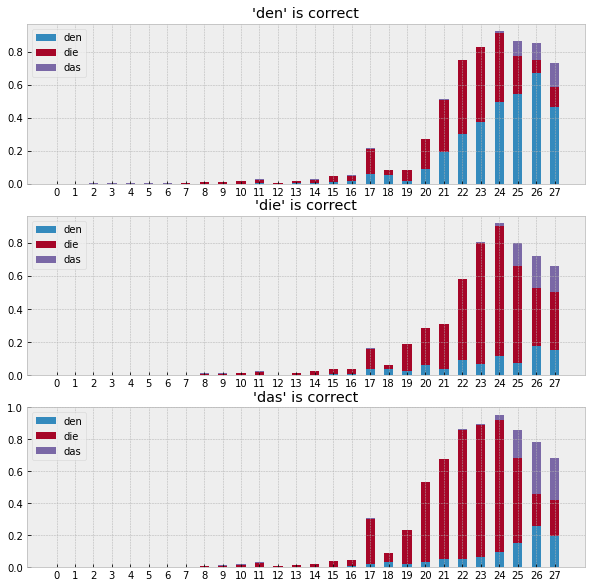

In [303]:
figure = plt.figure(figsize=(10,10))
axis = figure.subplots(3, 1)

weigths_den = {
    "den": probs_den_gptj[:, :, token_ids_gptj_sorted.index('den')].mean(axis=0).detach().numpy(),
    "die": probs_den_gptj[:, :, token_ids_gptj_sorted.index('die')].mean(axis=0).detach().numpy(),
    "das": probs_den_gptj[:, :, token_ids_gptj_sorted.index('das')].mean(axis=0).detach().numpy()
}
width = 0.5
bottom = np.zeros(NUM_LAYERS)
for article, weight_count in weigths_den.items():
    p = axis[0].bar(np.arange(NUM_LAYERS), weight_count, width, label=article, bottom=bottom)
    bottom += weight_count

weigths_die = {
    "den": probs_die_gptj[:, :, token_ids_gptj_sorted.index('den')].mean(axis=0).detach().numpy(),
    "die": probs_die_gptj[:, :, token_ids_gptj_sorted.index('die')].mean(axis=0).detach().numpy(),
    "das": probs_die_gptj[:, :, token_ids_gptj_sorted.index('das')].mean(axis=0).detach().numpy()
}
width = 0.5
bottom = np.zeros(NUM_LAYERS)
for article, weight_count in weigths_die.items():
    p = axis[1].bar(np.arange(NUM_LAYERS), weight_count, width, label=article, bottom=bottom)
    bottom += weight_count

# axis[0].xticks(np.arange(NUM_LAYERS), rotation=90)


weigths_das = {
    "den": probs_das_gptj[:, :, token_ids_gptj_sorted.index('den')].mean(axis=0).detach().numpy(),
    "die": probs_das_gptj[:, :, token_ids_gptj_sorted.index('die')].mean(axis=0).detach().numpy(),
    "das": probs_das_gptj[:, :, token_ids_gptj_sorted.index('das')].mean(axis=0).detach().numpy()
}

width = 0.5
bottom = np.zeros(NUM_LAYERS)
for article, weight_count in weigths_das.items():
    p = axis[2].bar(np.arange(NUM_LAYERS), weight_count, width, label=article, bottom=bottom)
    bottom += weight_count

# plt.plot(probs_den[:, 1:, 0].mean(axis=0).detach().numpy(), label="den")
# plt.plot(probs_den[:, 1:, 1].mean(axis=0).detach().numpy(), label="die")
# plt.plot(probs_den[:, 1:, 2].mean(axis=0).detach().numpy(), label="das")
# plt.ylim([0, 1])
# plt.xticks(np.arange(NUM_LAYERS), rotation=90)

axis[0].legend()
axis[1].legend()
axis[2].legend()
axis[0].set_xticks(np.arange(NUM_LAYERS))
axis[1].set_xticks(np.arange(NUM_LAYERS))
axis[2].set_xticks(np.arange(NUM_LAYERS))
axis[0].set_title("'den' is correct")
axis[1].set_title("'die' is correct")
axis[2].set_title("'das' is correct")

plt.ylim([0, 1])
plt.show()


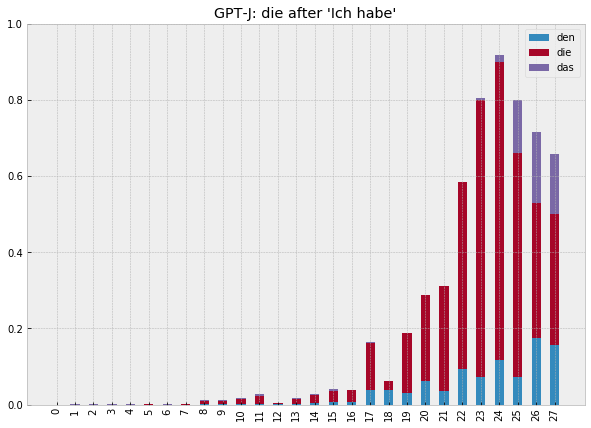

In [195]:
weigths_die = {
    "den": probs_die[:, :, token_ids_gptj_sorted.index('den')].mean(axis=0).detach().numpy(),
    "die": probs_die[:, :, token_ids_gptj_sorted.index('die')].mean(axis=0).detach().numpy(),
    "das": probs_die[:, :, token_ids_gptj_sorted.index('das')].mean(axis=0).detach().numpy()
}
width = 0.5

fig, ax = plt.subplots(figsize=(10,7))
bottom = np.zeros(NUM_LAYERS)

for article, weight_count in weigths_die.items():
    p = ax.bar(np.arange(NUM_LAYERS), weight_count, width, label=article, bottom=bottom)
    bottom += weight_count

# plt.plot(probs_den[:, 1:, 0].mean(axis=0).detach().numpy(), label="den")
# plt.plot(probs_den[:, 1:, 1].mean(axis=0).detach().numpy(), label="die")
# plt.plot(probs_den[:, 1:, 2].mean(axis=0).detach().numpy(), label="das")
# plt.ylim([0, 1])
plt.xticks(np.arange(NUM_LAYERS), rotation=90)

ax.legend()
plt.ylim([0, 1])
plt.title("GPT-J: die after 'Ich habe'")
plt.show()


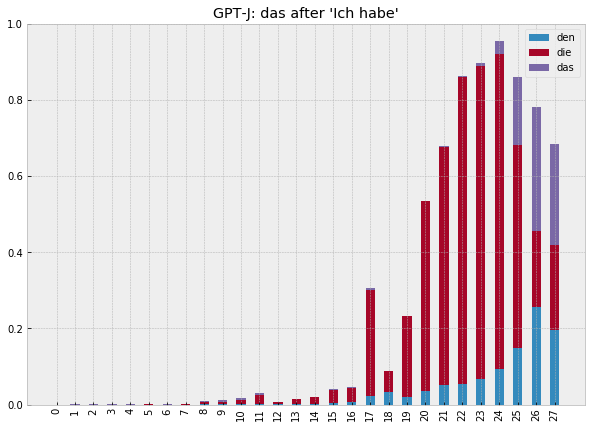

In [160]:
weigths_das = {
    "den": probs_das[:, :, token_ids_gptj_sorted.index('den')].mean(axis=0).detach().numpy(),
    "die": probs_das[:, :, token_ids_gptj_sorted.index('die')].mean(axis=0).detach().numpy(),
    "das": probs_das[:, :, token_ids_gptj_sorted.index('das')].mean(axis=0).detach().numpy()
}
width = 0.5

fig, ax = plt.subplots(figsize=(10,7))
bottom = np.zeros(NUM_LAYERS)

for article, weight_count in weigths_das.items():
    p = ax.bar(np.arange(NUM_LAYERS), weight_count, width, label=article, bottom=bottom)
    bottom += weight_count

# plt.plot(probs_den[:, 1:, 0].mean(axis=0).detach().numpy(), label="den")
# plt.plot(probs_den[:, 1:, 1].mean(axis=0).detach().numpy(), label="die")
# plt.plot(probs_den[:, 1:, 2].mean(axis=0).detach().numpy(), label="das")
# plt.ylim([0, 1])
plt.xticks(np.arange(NUM_LAYERS), rotation=90)

ax.legend()
plt.ylim([0, 1])
plt.title("GPT-J: das after 'Ich habe'")
plt.show()

In [228]:
probs_full_gptj[:, :, token_ids_gptj_sorted.index('den')].mean(axis=0)

tensor([6.4217e-06, 6.7230e-06, 5.8656e-06, 3.8724e-06, 3.0542e-06, 6.5567e-06,
        1.4332e-05, 3.9526e-05, 1.3535e-04, 3.3981e-04, 3.8242e-04, 6.8285e-04,
        1.7912e-04, 5.9612e-04, 2.5772e-03, 8.5052e-03, 1.0830e-02, 4.5628e-02,
        4.3445e-02, 2.2457e-02, 7.2579e-02, 1.1076e-01, 1.8441e-01, 2.1038e-01,
        2.9700e-01, 3.0810e-01, 4.2172e-01, 3.0580e-01],
       grad_fn=<MeanBackward1>)

In [230]:
for l in range(NUM_LAYERS):
    dataset_gptj_habe[f'perf_ger_layer_{l}_prob'] = dataset_gptj_habe.apply(
        lambda row: word2prob(row, 'perf_ger', token_ids_gptj_sorted, l, probs_full_gptj), axis=1
    ).astype('float')
    dataset_gptj_habe[f'noun_ger_layer_{l}_prob'] = dataset_gptj_habe.apply(
        lambda row: word2prob(row, 'noun_ger', token_ids_gptj_sorted, l, probs_full_gptj), axis=1
    ).astype('float')
    dataset_gptj_habe[f'perf_eng_layer_{l}_prob'] = dataset_gptj_habe.apply(
        lambda row: word2prob(row, 'perf_eng', token_ids_gptj_sorted, l, probs_full_gptj), axis=1
    ).astype('float')
    dataset_gptj_habe[f'past_eng_layer_{l}_prob'] = dataset_gptj_habe.apply(
        lambda row: word2prob(row, 'past_eng', token_ids_gptj_sorted, l, probs_full_gptj), axis=1
    ).astype('float')
    dataset_gptj_habe[f'noun_eng_layer_{l}_prob'] = dataset_gptj_habe.apply(
        lambda row: word2prob(row, 'noun_eng', token_ids_gptj_sorted, l, probs_full_gptj), axis=1
    ).astype('float')
    dataset_gptj_habe[f'art_ger_layer_{l}_prob'] = dataset_gptj_habe.apply(
        lambda row: word2prob(row, 'art_ger', token_ids_gptj_sorted, l, probs_full_gptj), axis=1
    ).astype('float')


In [231]:
dataset_gptj_habe.head()

,sentence_f,sentence_e,coll_freq,logdice,obj_freq,perf_ger,perf_eng,past_eng,art_ger,noun_ger,...,perf_eng_layer_26_prob,past_eng_layer_26_prob,noun_eng_layer_26_prob,art_ger_layer_26_prob,perf_ger_layer_27_prob,noun_ger_layer_27_prob,perf_eng_layer_27_prob,past_eng_layer_27_prob,noun_eng_layer_27_prob,art_ger_layer_27_prob
115,Die Frau hat den Apfel dazugegeben,The woman added the apple,75,4.88,314787,dazugegeben,added,added,den,Apfel,...,5.161762e-05,5.161762e-05,0.000024,0.405518,0.187256,0.001430,0.000045,0.000045,0.000045,0.212158
56,Ich habe den Apfel geraspelt,I grated the apple,157,6.74,314787,geraspelt,grated,grated,den,Apfel,...,1.230240e-04,1.230240e-04,0.000006,0.318604,0.001040,0.007751,0.000368,0.000368,0.000014,0.340088
120,Ich habe den Apfel entdeckt,I discovered the apple,72,1.18,314787,entdeckt,discovered,discovered,den,Apfel,...,1.192093e-07,1.192093e-07,0.000033,0.337891,0.000411,0.003363,0.000001,0.000001,0.000086,0.233887
30,Der Mann hat den Apfel gehalten,The man held the apple,358,1.91,314787,gehalten,held,held,den,Apfel,...,1.370907e-06,1.370907e-06,0.000004,0.430420,0.000533,0.003290,0.000009,0.000009,0.000012,0.245483
137,Er hat den Apfel gemalt,He painted the apple,57,3.41,314787,gemalt,painted,painted,den,Apfel,...,2.384186e-07,2.384186e-07,0.000002,0.395020,0.000633,0.004974,0.000001,0.000001,0.000009,0.166016


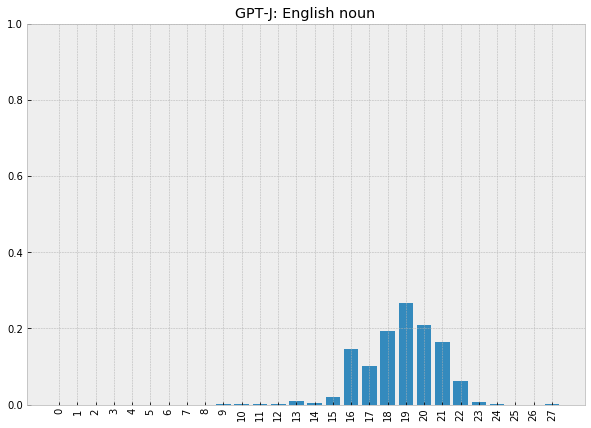

In [232]:
plot_probs = dataset_gptj_habe[
    [f'noun_eng_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()

fig, ax = plt.subplots(figsize=(10,7))
p = ax.bar(np.arange(NUM_LAYERS), plot_probs)

plt.xticks(np.arange(NUM_LAYERS), rotation=90)
plt.ylim([0, 1])
plt.title("GPT-J: English noun")
plt.show()

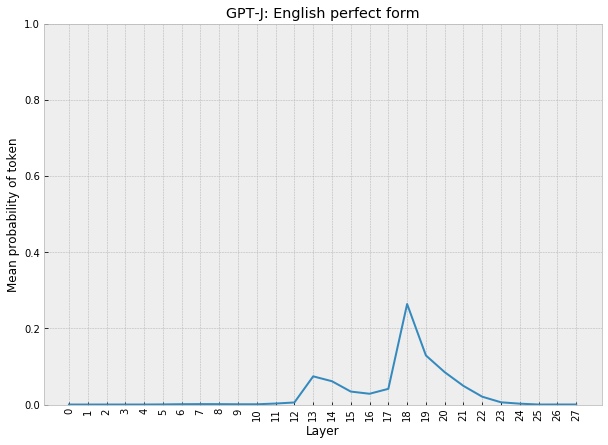

In [244]:
plot_perf_probs = dataset_gptj_habe[
    [f'perf_eng_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()

fig, ax = plt.subplots(figsize=(10,7))
p = ax.plot(np.arange(NUM_LAYERS), plot_perf_probs)

plt.xticks(np.arange(NUM_LAYERS), rotation=90)
plt.ylim([0, 1])
plt.title("GPT-J: English perfect form")
plt.xlabel("Layer")
plt.ylabel("Mean probability of token")
plt.show()

In [259]:
different_verbforms.perf_eng_layer_18_prob.mean()

0.014511048793792725

In [ ]:
dataset_gptj_habe.perf_eng_layer_18_prob.mean()

In [248]:
different_verbforms = dataset_gptj_habe[dataset_gptj_habe.perf_eng != dataset_gptj_habe.past_eng]
different_verbforms.tail()

,sentence_f,sentence_e,coll_freq,logdice,obj_freq,perf_ger,perf_eng,past_eng,art_ger,noun_ger,...,perf_eng_layer_26_prob,past_eng_layer_26_prob,noun_eng_layer_26_prob,art_ger_layer_26_prob,perf_ger_layer_27_prob,noun_ger_layer_27_prob,perf_eng_layer_27_prob,past_eng_layer_27_prob,noun_eng_layer_27_prob,art_ger_layer_27_prob
659,Die Frau hat das Spiel begonnen,The woman began the game,10304,7.48,5774929,begonnen,begun,began,das,Spiel,...,6.351471e-04,6.351471e-04,0.000011,0.264404,0.013336,0.000966,0.002930,0.002930,0.000017,0.124573
685,Er hat das Spiel genommen,He took the game,7006,5.10,5774929,genommen,taken,took,das,Spiel,...,5.960464e-08,5.960464e-08,0.000020,0.534180,0.000235,0.001776,0.000004,0.000004,0.000093,0.414551
687,Die Frau hat das Spiel genommen,The woman took the game,7006,5.10,5774929,genommen,taken,took,das,Spiel,...,1.192093e-07,1.192093e-07,0.000008,0.348877,0.000700,0.001043,0.000004,0.000004,0.000031,0.317627
628,Ich habe das Spiel gesehen,I saw the game,20910,7.00,5774929,gesehen,seen,saw,das,Spiel,...,1.788139e-07,1.788139e-07,0.000015,0.599609,0.036163,0.000632,0.000006,0.000006,0.000109,0.454590
786,Der Mann hat das Spiel geholt,The man took the game,2533,5.40,5774929,geholt,taken,took,das,Spiel,...,5.960464e-08,5.960464e-08,0.000016,0.610352,0.000189,0.000951,0.000002,0.000002,0.000052,0.532715


In [251]:
dataset_gptj_habe.tail()

,sentence_f,sentence_e,coll_freq,logdice,obj_freq,perf_ger,perf_eng,past_eng,art_ger,noun_ger,...,perf_eng_layer_26_prob,past_eng_layer_26_prob,noun_eng_layer_26_prob,art_ger_layer_26_prob,perf_ger_layer_27_prob,noun_ger_layer_27_prob,perf_eng_layer_27_prob,past_eng_layer_27_prob,noun_eng_layer_27_prob,art_ger_layer_27_prob
673,Er hat das Spiel geboten,He offered the game,7872,5.13,5774929,geboten,offered,offered,das,Spiel,...,1.120567e-05,1.120567e-05,0.000023,0.332031,0.007511,0.002186,0.000018,0.000018,0.000100,0.239136
731,Die Frau hat das Spiel übertragen,The woman broadcast the game,3596,6.20,5774929,übertragen,broadcast,broadcast,das,Spiel,...,2.360344e-05,2.360344e-05,0.000011,0.216797,0.002010,0.000428,0.000112,0.000112,0.000050,0.228638
780,Ich habe das Spiel verbessert,I bettered the game,2628,5.49,5774929,verbessert,bettered,bettered,das,Spiel,...,2.604723e-05,2.604723e-05,0.000002,0.207642,0.000456,0.000314,0.000542,0.000542,0.000021,0.301025
786,Der Mann hat das Spiel geholt,The man took the game,2533,5.40,5774929,geholt,taken,took,das,Spiel,...,5.960464e-08,5.960464e-08,0.000016,0.610352,0.000189,0.000951,0.000002,0.000002,0.000052,0.532715
801,Er hat das Spiel empfohlen,He recommended the game,2233,5.36,5774929,empfohlen,recommended,recommended,das,Spiel,...,1.091003e-03,1.091003e-03,0.000080,0.167114,0.004349,0.001423,0.000301,0.000301,0.000166,0.152100


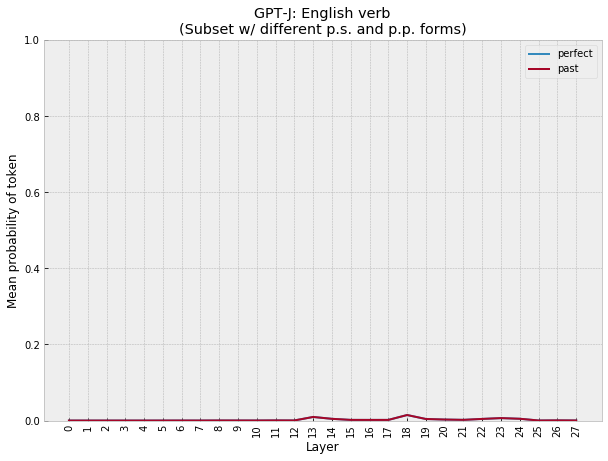

In [265]:
plot_perf_probs = different_verbforms[
    [f'perf_eng_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()
plot_past_probs = different_verbforms[
    [f'past_eng_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()


fig, ax = plt.subplots(figsize=(10,7))
p = ax.plot(np.arange(NUM_LAYERS), plot_perf_probs, label="perfect")
p = ax.plot(np.arange(NUM_LAYERS), plot_past_probs, label="past")

plt.xticks(np.arange(NUM_LAYERS), rotation=90)
plt.ylim([0, 1])
plt.title("GPT-J: English verb\n(Subset w/ different p.s. and p.p. forms)")
plt.xlabel("Layer")
plt.ylabel("Mean probability of token")
plt.legend()
plt.show()

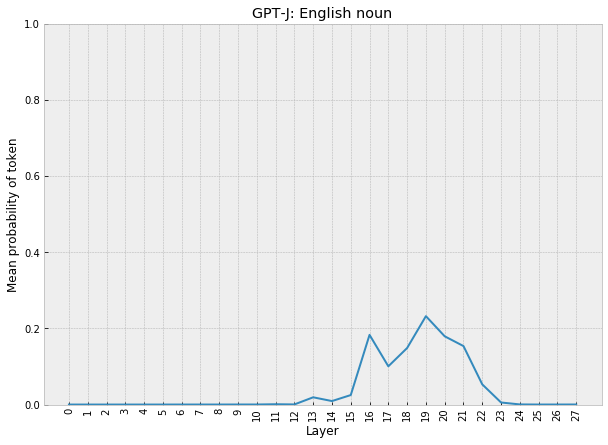

In [255]:
plot_noun_probs = different_verbforms[
    [f'noun_eng_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()


fig, ax = plt.subplots(figsize=(10,7))
p = ax.plot(np.arange(NUM_LAYERS), plot_noun_probs)

plt.xticks(np.arange(NUM_LAYERS), rotation=90)
plt.ylim([0, 1])
plt.title("GPT-J: English noun")
plt.xlabel("Layer")
plt.ylabel("Mean probability of token")
plt.show()

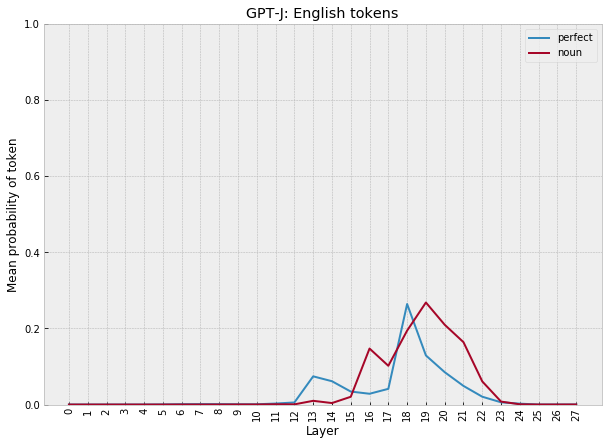

In [246]:
plot_perf_probs = dataset_gptj_habe[
    [f'perf_eng_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()
plot_noun_probs = dataset_gptj_habe[
    [f'noun_eng_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()
# plot_art_probs = dataset_gptj_habe[
#     [f'art_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
# ].mean()

fig, ax = plt.subplots(figsize=(10,7))
p = ax.plot(np.arange(NUM_LAYERS), plot_perf_probs, label="perfect")
p = ax.plot(np.arange(NUM_LAYERS), plot_noun_probs, label="noun")
# p = ax.plot(np.arange(NUM_LAYERS), plot_art_probs)

plt.xticks(np.arange(NUM_LAYERS), rotation=90)
plt.ylim([0, 1])
plt.title("GPT-J: English tokens")
plt.xlabel("Layer")
plt.ylabel("Mean probability of token")
plt.legend()
plt.show()

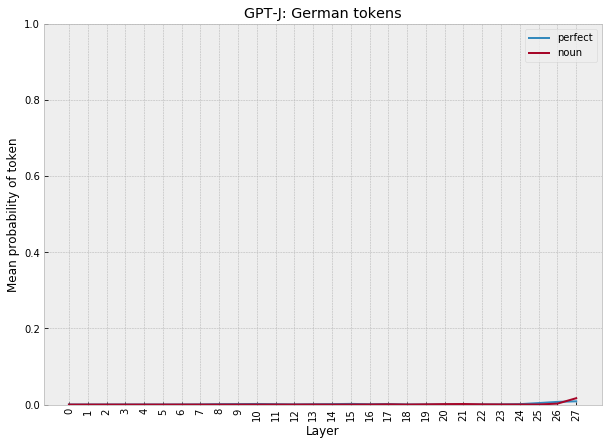

In [247]:
plot_perf_probs = dataset_gptj_habe[
    [f'perf_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()
plot_noun_probs = dataset_gptj_habe[
    [f'noun_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()
# plot_art_probs = dataset_gptj_habe[
#     [f'art_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
# ].mean()

fig, ax = plt.subplots(figsize=(10,7))
p = ax.plot(np.arange(NUM_LAYERS), plot_perf_probs, label="perfect")
p = ax.plot(np.arange(NUM_LAYERS), plot_noun_probs, label="noun")
# p = ax.plot(np.arange(NUM_LAYERS), plot_art_probs)

plt.xticks(np.arange(NUM_LAYERS), rotation=90)
plt.ylim([0, 1])
plt.title("GPT-J: German tokens")
plt.xlabel("Layer")
plt.ylabel("Mean probability of token")
plt.legend()
plt.show()

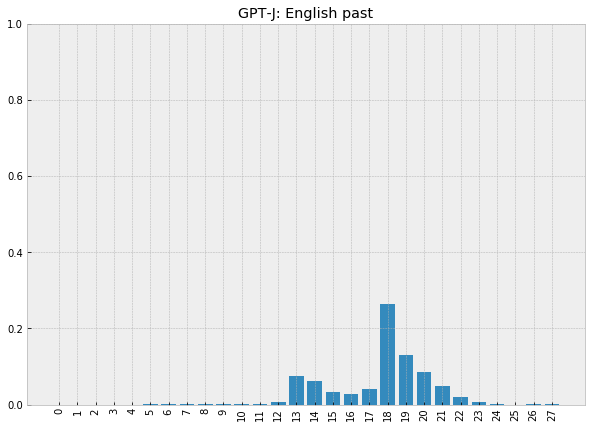

In [235]:
plot_probs = dataset_gptj_habe[
    [f'past_eng_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()

fig, ax = plt.subplots(figsize=(10,7))
p = ax.bar(np.arange(NUM_LAYERS), plot_probs)

plt.xticks(np.arange(NUM_LAYERS), rotation=90)
plt.ylim([0, 1])
plt.title("GPT-J: English past")
plt.show()

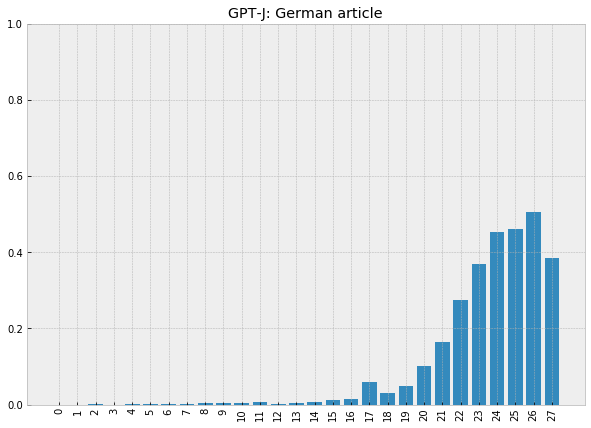

In [236]:
plot_probs = dataset_gptj_habe[
    [f'art_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()

fig, ax = plt.subplots(figsize=(10,7))
p = ax.bar(np.arange(NUM_LAYERS), plot_probs)

plt.xticks(np.arange(NUM_LAYERS), rotation=90)
plt.ylim([0, 1])
plt.title("GPT-J: German article")
plt.show()

In [168]:
dataset_gptj_habe.art_ger_layer_27_prob

115    0.187256
56     0.256592
120    0.300293
30     0.257324
137    0.241577
         ...   
673    0.007511
731    0.009438
780    0.031738
786    0.003731
801    0.014946
Name: art_ger_layer_27_prob, Length: 560, dtype: float64

In [169]:
dataset_gptj_habe.tail()

,sentence_f,sentence_e,coll_freq,logdice,obj_freq,perf_ger,perf_eng,past_eng,art_ger,noun_ger,...,perf_eng_layer_26_prob,past_eng_layer_26_prob,noun_eng_layer_26_prob,art_ger_layer_26_prob,perf_ger_layer_27_prob,noun_ger_layer_27_prob,perf_eng_layer_27_prob,past_eng_layer_27_prob,noun_eng_layer_27_prob,art_ger_layer_27_prob
673,Er hat das Spiel geboten,He offered the game,7872,5.13,5774929,geboten,offered,offered,das,Spiel,...,0.000007,0.000007,0.000021,0.003689,7.511139e-03,1.603365e-05,0.000156,1.559258e-04,0.000444,0.007511
731,Die Frau hat das Spiel übertragen,The woman broadcast the game,3596,6.20,5774929,übertragen,broadcast,broadcast,das,Spiel,...,0.000609,0.000609,0.000003,0.005959,0.000000e+00,3.039837e-06,0.001200,1.199722e-03,0.000041,0.009438
780,Ich habe das Spiel verbessert,I bettered the game,2628,5.49,5774929,verbessert,bettered,bettered,das,Spiel,...,0.000243,0.000243,0.000004,0.010666,0.000000e+00,4.887581e-06,0.001129,1.129150e-03,0.000140,0.031738
786,Der Mann hat das Spiel geholt,The man took the game,2533,5.40,5774929,geholt,taken,took,das,Spiel,...,0.000002,0.000000,0.000010,0.001089,3.730774e-03,8.940697e-07,0.000023,1.192093e-07,0.000169,0.003731
801,Er hat das Spiel empfohlen,He recommended the game,2233,5.36,5774929,empfohlen,recommended,recommended,das,Spiel,...,0.000000,0.000000,0.000013,0.006790,5.960464e-08,2.563000e-05,0.000000,0.000000e+00,0.000249,0.014946


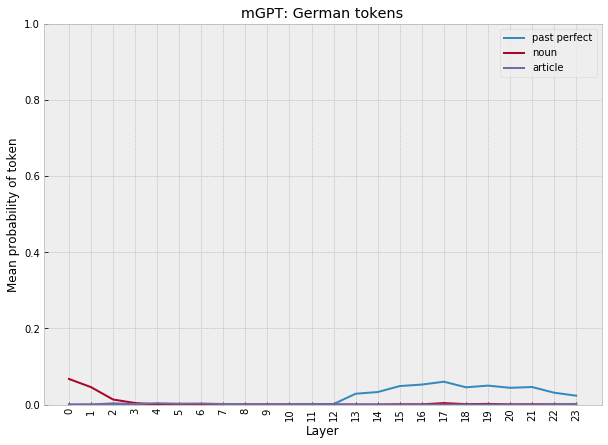

In [22]:
plot_perf_probs = dataset_mgpt_subject[
    [f'perf_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()
plot_noun_probs = dataset_mgpt_subject[
    [f'noun_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()
plot_art_probs = dataset_mgpt_subject[
    [f'art_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()

fig, ax = plt.subplots(figsize=(10,7))
p = ax.plot(np.arange(NUM_LAYERS), plot_perf_probs, label="past perfect")
p = ax.plot(np.arange(NUM_LAYERS), plot_noun_probs, label="noun")
p = ax.plot(np.arange(NUM_LAYERS), plot_art_probs, label="article")

plt.xticks(np.arange(NUM_LAYERS), rotation=90)
plt.ylim([0, 1])
plt.title("mGPT: German tokens")
plt.xlabel("Layer")
plt.ylabel("Mean probability of token")
plt.legend()
plt.show()

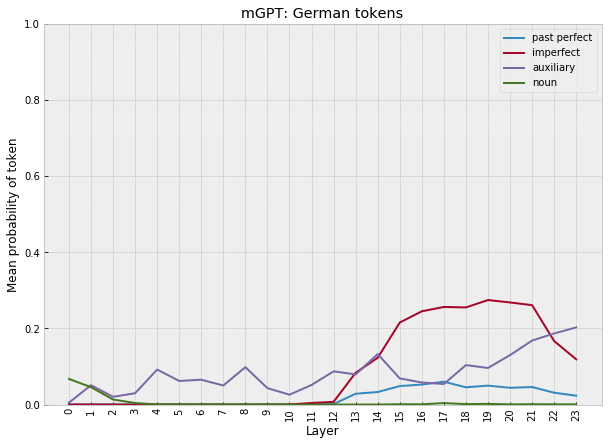

In [41]:
plot_perf_probs = dataset_mgpt_subject[
    [f'perf_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()
plot_impf_probs = dataset_mgpt_subject[
    [f'impf_3_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()
plot_aux_probs = dataset_mgpt_subject[
    [f'aux_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()
plot_noun_probs = dataset_mgpt_subject[
    [f'noun_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()


fig, ax = plt.subplots(figsize=(10,7))
p = ax.plot(np.arange(NUM_LAYERS), plot_perf_probs, label="past perfect")
p = ax.plot(np.arange(NUM_LAYERS), plot_impf_probs, label="imperfect")
p = ax.plot(np.arange(NUM_LAYERS), plot_aux_probs, label="auxiliary")
p = ax.plot(np.arange(NUM_LAYERS), plot_noun_probs, label="noun")
# p = ax.plot(np.arange(NUM_LAYERS), plot_art_probs, label="article")

plt.xticks(np.arange(NUM_LAYERS), rotation=90)
plt.ylim([0, 1])
plt.title("mGPT: German tokens")
plt.xlabel("Layer")
plt.ylabel("Mean probability of token")
plt.legend()
plt.show()

In [50]:
from constants import RANDOM_STATE

NUM_LAYERS = 28
SAMPLE_SIZE = 70
SENTENCE_CSV_PATH_HABE = "data/dataset_gptj_haben.csv"
SENTENCE_CSV_PATH_EMPTY = "data/dataset_gptj_empty.csv"
SENTENCE_CSV_PATH_SUBJECT = "data/dataset_gptj_subject.csv"

# loading the sentence dataset
dataset_gptj_habe_full = pd.read_csv(SENTENCE_CSV_PATH_HABE, index_col=0)
dataset_gptj_habe = dataset_gptj_habe_full.groupby('noun_ger').sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE) # equalizing the dataset

dataset_gptj_empty_full = pd.read_csv(SENTENCE_CSV_PATH_EMPTY, index_col=0)
dataset_gptj_empty = dataset_gptj_empty_full.groupby('noun_ger').sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE) # equalizing the dataset


dataset_gptj_subject_full = pd.read_csv(SENTENCE_CSV_PATH_SUBJECT, index_col=0)
dataset_gptj_subject = dataset_gptj_subject_full.groupby('noun_ger').sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE) # equalizing the dataset



In [52]:
dataset_gptj_subject['sentence_id'] = dataset_gptj_subject.index

In [53]:
probs_full_gptj_subject = []
for i in dataset_gptj_subject_full.index:
    file = f"data/probs/gptj_subject/{i}.pt"
    probs_full_gptj_subject.append(torch.load(file))
probs_full_gptj_subject = torch.stack(probs_full_gptj_subject)
probs_full_gptj_subject = probs_full_gptj_subject[:, 1:, :]

In [54]:
with open("data/gptj_tokenids.json") as f:
    token2id_gptj = json.load(f)

In [55]:
token_ids_gptj_sorted = sorted(token2id_gptj.keys(), key = lambda x: token2id_gptj[x])

In [56]:
for l in range(NUM_LAYERS):
    dataset_gptj_subject[f'perf_ger_layer_{l}_prob'] = dataset_gptj_subject.apply(
        lambda row: word2prob(row, 'perf_ger', token_ids_gptj_sorted, l, probs_full_gptj_subject), axis=1
    ).astype('float')
    dataset_gptj_subject[f'noun_ger_layer_{l}_prob'] = dataset_gptj_subject.apply(
        lambda row: word2prob(row, 'noun_ger', token_ids_gptj_sorted, l, probs_full_gptj_subject), axis=1
    ).astype('float')
    dataset_gptj_subject[f'perf_eng_layer_{l}_prob'] = dataset_gptj_subject.apply(
        lambda row: word2prob(row, 'perf_eng', token_ids_gptj_sorted, l, probs_full_gptj_subject), axis=1
    ).astype('float')
    dataset_gptj_subject[f'past_eng_layer_{l}_prob'] = dataset_gptj_subject.apply(
        lambda row: word2prob(row, 'past_eng', token_ids_gptj_sorted, l, probs_full_gptj_subject), axis=1
    ).astype('float')
    dataset_gptj_subject[f'noun_eng_layer_{l}_prob'] = dataset_gptj_subject.apply(
        lambda row: word2prob(row, 'noun_eng', token_ids_gptj_sorted, l, probs_full_gptj_subject), axis=1
    ).astype('float')
    dataset_gptj_subject[f'art_ger_layer_{l}_prob'] = dataset_gptj_subject.apply(
        lambda row: word2prob(row, 'art_ger', token_ids_gptj_sorted, l, probs_full_gptj_subject), axis=1
    ).astype('float')
    dataset_gptj_subject[f'impf_3_layer_{l}_prob'] = dataset_gptj_subject.apply(
        lambda row: word2prob(row, 'impf_3', token_ids_gptj_sorted, l, probs_full_gptj_subject), axis=1
    ).astype('float')
    dataset_gptj_subject[f'aux_ger_layer_{l}_prob'] = dataset_gptj_subject.apply(
        lambda row: word2prob(row, 'aux_ger', token_ids_gptj_sorted, l, probs_full_gptj_subject), axis=1
    ).astype('float')

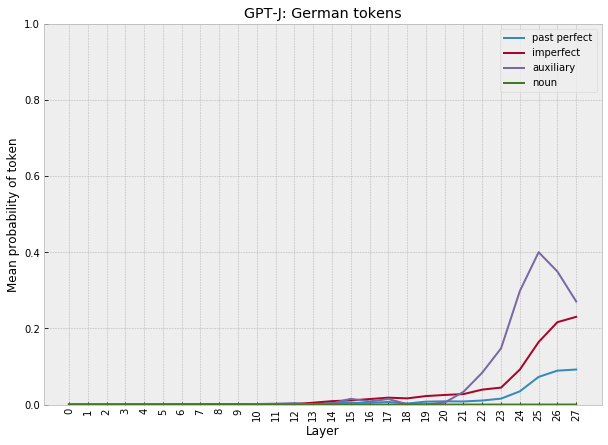

In [64]:
plot_perf_probs = dataset_gptj_subject[
    [f'perf_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()
plot_impf_probs = dataset_gptj_subject[
    [f'impf_3_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()
plot_aux_probs = dataset_gptj_subject[
    [f'aux_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()
plot_noun_probs = dataset_gptj_subject[
    [f'noun_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()


fig, ax = plt.subplots(figsize=(10,7))
p = ax.plot(np.arange(NUM_LAYERS), plot_perf_probs, label="past perfect")
p = ax.plot(np.arange(NUM_LAYERS), plot_impf_probs, label="imperfect")
p = ax.plot(np.arange(NUM_LAYERS), plot_aux_probs, label="auxiliary")
p = ax.plot(np.arange(NUM_LAYERS), plot_noun_probs, label="noun")
# p = ax.plot(np.arange(NUM_LAYERS), plot_art_probs, label="article")

plt.xticks(np.arange(NUM_LAYERS), rotation=90)
plt.ylim([0, 1])
plt.title("GPT-J: German tokens")
plt.xlabel("Layer")
plt.ylabel("Mean probability of token")
plt.legend()
plt.show()

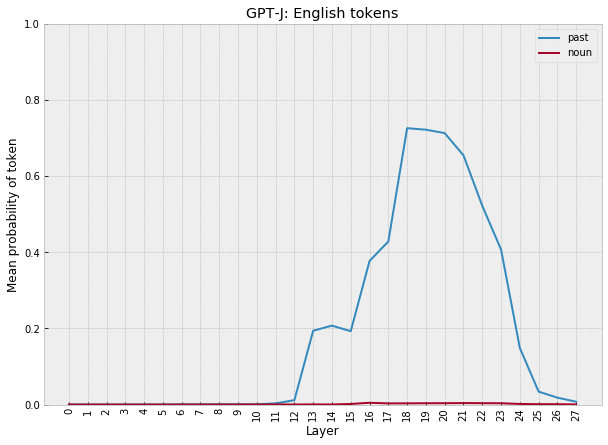

In [65]:
plot_perf_probs = dataset_gptj_subject[
    [f'past_eng_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()
plot_noun_probs = dataset_gptj_subject[
    [f'noun_eng_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()


fig, ax = plt.subplots(figsize=(10,7))
p = ax.plot(np.arange(NUM_LAYERS), plot_perf_probs, label="past")
# p = ax.plot(np.arange(NUM_LAYERS), plot_impf_probs, label="imperfect")
# p = ax.plot(np.arange(NUM_LAYERS), plot_aux_probs, label="auxiliary")
p = ax.plot(np.arange(NUM_LAYERS), plot_noun_probs, label="noun")
# p = ax.plot(np.arange(NUM_LAYERS), plot_art_probs, label="article")

plt.xticks(np.arange(NUM_LAYERS), rotation=90)
plt.ylim([0, 1])
plt.title("GPT-J: English tokens")
plt.xlabel("Layer")
plt.ylabel("Mean probability of token")
plt.legend()
plt.show()

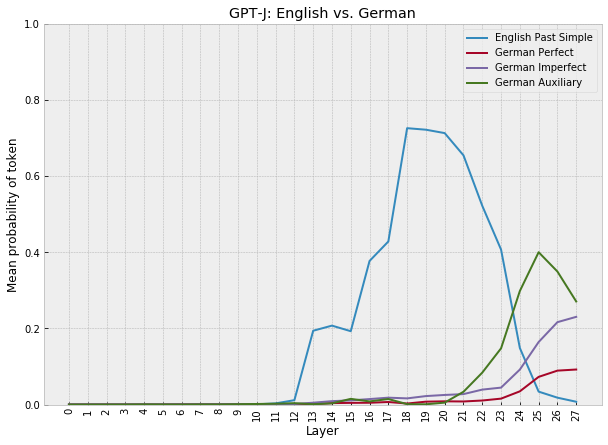

In [67]:
plot_eng_probs = dataset_gptj_subject[
    [f'past_eng_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()
plot_ger_probs = dataset_gptj_subject[
    [f'perf_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()
plot_impf_probs = dataset_gptj_subject[
    [f'impf_3_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()
plot_aux_probs = dataset_gptj_subject[
    [f'aux_ger_layer_{l}_prob' for l in range(NUM_LAYERS)]
].mean()


fig, ax = plt.subplots(figsize=(10,7))
p = ax.plot(np.arange(NUM_LAYERS), plot_eng_probs, label="English Past Simple")
# p = ax.plot(np.arange(NUM_LAYERS), plot_impf_probs, label="imperfect")
# p = ax.plot(np.arange(NUM_LAYERS), plot_aux_probs, label="auxiliary")
p = ax.plot(np.arange(NUM_LAYERS), plot_ger_probs, label="German Perfect")
p = ax.plot(np.arange(NUM_LAYERS), plot_impf_probs, label="German Imperfect")
p = ax.plot(np.arange(NUM_LAYERS), plot_aux_probs, label="German Auxiliary")
# p = ax.plot(np.arange(NUM_LAYERS), plot_art_probs, label="article")

plt.xticks(np.arange(NUM_LAYERS), rotation=90)
plt.ylim([0, 1])
plt.title("GPT-J: English vs. German")
plt.xlabel("Layer")
plt.ylabel("Mean probability of token")
plt.legend()
plt.show()